<a href="https://colab.research.google.com/github/zize-a11y/-Computer-Vision-Dasar-Python-Bagian1/blob/main/Pertemuan%204/4.1%20auto-annotation-grounding-dino-autodistill.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Auto Annotation using Grounding DINO + Autodistill

- Autodistill :
    - Autodistill uses *big, slower foundation models* to train small, faster supervised models.
    - Using autodistill, you can go from *unlabeled images* to inference with no human intervention in between.
    - As foundation models get better and better they will increasingly be able to augment or replace humans in the labeling process.
    <img src="https://github.com/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/resource/autodistil.jpg?raw=1" width="800px">
    - More about Autodistill Usage (https://docs.autodistill.com/quickstart/#step-5-label-a-dataset)
- Grounding DINO :
    - Grounding DINO is a `self-supervised learning` algorithm that combines **DINO** (*DETR with Improved deNoising anchor boxes*) with **GLIP** (*Grounded Language-Image Pre-training*).
    - Grounding DINO linking textual descriptions (*performed by GLIP*) to their respective visual representations (*performed by DINO*).
    - Grounding DINO can detect `arbitrary objects` with `human inputs` such as `category names` or `referring expressions`.
    <img src="https://github.com/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/resource/grounding-dino.png?raw=1" width="800px"><br><br>
    <img src="https://github.com/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/resource/model_explan1.png?raw=1" width="800px"><br><br>
    <img src="https://github.com/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/resource/model_explan2.png?raw=1" width="800px"><br><br>
    - More about Grounding DINO (https://github.com/IDEA-Research/GroundingDINO)
    - DINO Paper (https://arxiv.org/pdf/2203.03605)
    - GLIP Paper (https://arxiv.org/pdf/2112.03857)
    - Grounding DINO Paper (https://arxiv.org/abs/2303.05499)

## What we will do
- Setting GPU Environment
- Installing Autodistill & Grounding DINO
- Download Dataset from Google Drive Shared Link (`Dataset Scissors.zip`)
- Perform Automatic Annotation using Autodistill & Grounding DINO
- Upload Dataset & Annotation to Roboflow

⚠️⚠️⚠️ *Please open this notebook in Google Colab* by click below link ⚠️⚠️⚠️<br><br>
<a href="https://colab.research.google.com/github/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/4.1 auto-annotation-grounding-dino-autodistill.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 3.1 Connect GPU Environment

- Click `Connect` button in top right Google Colab notebook,<br>
<img src="https://github.com/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/resource/cl-connect-gpu.png?raw=1" width="250px">
- If connecting process completed, it will turn to something look like this<br>
<img src="https://github.com/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/resource/cl-connect-gpu-success.png?raw=1" width="250px">

- Check GPU connected into Colab environment is active

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!nvidia-smi

Tue Apr 21 22:43:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

import os
HOME = os.getcwd()
print("HOME:", HOME)

HOME: /content


## 3.2 Installing Autodistill & Grounding DINO

In [4]:
!pip install roboflow autodistill autodistill-grounding-dino supervision -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.4/82.4 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 139.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 27.2 MB/s eta 0:00:00


## 3.3 Download Dataset from Google Drive
- We will use sample dataset [Dataset Scissors.zip](https://drive.google.com/file/d/1PFUlHCwxHAz-zMpP7UD-L47dRAzbrqWi/view) from GDrive.
- If you want to use **your own dataset**, just upload dataset to GDrive and share as **public link** in **ZIP** format.<br>
<img src="https://github.com/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/resource/gd-share.png?raw=1" width="400px">
- Open the shared link in browser, and copy the `GDrive ID` in browser address bar.<br>
<img src="https://github.com/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/resource/gd-id.png?raw=1" width="600px">

- Paste the GDrive ID as value `gdrive_id` variable below,

In [1]:
!pip install gdown

import gdown

DATASET_NAME = 'Scissors_Dataset'

# default using gdrive_id Dataset `Scissors.zip` (1PFUlHCwxHAz-zMpP7UD-L47dRAzbrqWi)
gdrive_id = '1PFUlHCwxHAz-zMpP7UD-L47dRAzbrqWi' # <-----  ⚠️⚠️⚠️ USE YOUR OWN GDrive ID ⚠️⚠️⚠️

# download zip from GDrive
url = 'https://drive.google.com/uc?id=' + gdrive_id
gdown.download(url, DATASET_NAME + ".zip", quiet=False)

# unzip dataset
!unzip -j {DATASET_NAME}.zip -d {DATASET_NAME}

Downloading...
From (original): https://drive.google.com/uc?id=1PFUlHCwxHAz-zMpP7UD-L47dRAzbrqWi
From (redirected): https://drive.google.com/uc?id=1PFUlHCwxHAz-zMpP7UD-L47dRAzbrqWi&confirm=t&uuid=df7a20c2-ee32-4664-abea-f5735bc5a229
To: /content/Scissors_Dataset.zip
100%|██████████| 30.9M/30.9M [00:00<00:00, 53.1MB/s]


Archive:  Scissors_Dataset.zip
  inflating: Scissors_Dataset/IMG_20240914_081410.jpg  
  inflating: Scissors_Dataset/IMG_20240914_081412.jpg  
  inflating: Scissors_Dataset/IMG_20240914_081418.jpg  
  inflating: Scissors_Dataset/IMG_20240914_081421.jpg  
  inflating: Scissors_Dataset/IMG_20240914_081424.jpg  
  inflating: Scissors_Dataset/IMG_20240914_081426.jpg  
  inflating: Scissors_Dataset/IMG_20240914_081429.jpg  
  inflating: Scissors_Dataset/IMG_20240914_081430.jpg  
  inflating: Scissors_Dataset/IMG_20240914_081434.jpg  
  inflating: Scissors_Dataset/IMG_20240914_081436.jpg  
  inflating: Scissors_Dataset/IMG_20240914_081439.jpg  
  inflating: Scissors_Dataset/IMG_20240914_081441.jpg  
  inflating: Scissors_Dataset/IMG_20240914_081453.jpg  
  inflating: Scissors_Dataset/IMG_20240914_081457.jpg  
  inflating: Scissors_Dataset/IMG_20240914_081510.jpg  
  inflating: Scissors_Dataset/IMG_20240914_081512.jpg  
  inflating: Scissors_Dataset/IMG_20240914_081531.jpg  
  inflating: Scis

## 3.4 Automatic Annotation using Autodistill & Grounding DINO

- Below, we import the dependencies required to running Autodistill & Grounding DINO

In [4]:
pip install autodistill-grounding-dino

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.4/82.4 kB 10.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 27.2 MB/s eta 0:00:00
  Created wheel for rf-groundingdino: filename=rf_groundingdino-0.1.2-py2.py3-none-any.whl size=88734 sha256=c583e2c9242218eb8f9a33337139e7b6ecf278fd7968c7f2384b01a0c312dbb6
  Stored in directory: /root/.cache/pip/wheels/e1/4a/ca/86ae3ab93b9e04d9aecb76140b62cd0931d0aea6710a266ae9
Successfully built rf-groundingdino


In [6]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 146.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [2]:
from autodistill_grounding_dino import GroundingDINO
from autodistill.detection import CaptionOntology
import supervision as sv
import cv2
import os
import torch
import random
import numpy as np

torch.use_deterministic_algorithms(False)

Importing from timm.models.layers is deprecated, please import via timm.layers


#### 3.4.1 Label Images with Grounding DINO

- Below, we set an *ontology*. Ontologies map `prompts` -- *text given to a model for use in labelling data* -- to the `labels` you want your dataset to include.
- For example, the ontology `"red color apple": "apple"` will send the prompt `"red color apple"` to the base model (in this example Grounding DINO). All objects matching that prompt will be labelled `"apple"`.
- Example if we have multiple object to detect (`apple`, `bottle`, `cap`):
    ```
    {
        "red color apple": "apple"
        "milk bottle": "bottle",
        "blue cap": "cap"
    }
    ```

In [3]:
# import
from autodistill_grounding_dino import GroundingDINO
from autodistill.detection import CaptionOntology

In [2]:
import transformers
print(transformers.__version__)

4.38.2


In [4]:
def NMS_detection(predictions):
  # Step 1: filter only predistion results with confidence > 0.5 (50%)
  # you can change the threshold to other number preferred, e.g (0.75 for confidence above 75%)
  predictions = predictions[predictions.confidence > 0.5]

  # Step 2: Perform Non-Maximum Suppression
  boxes = torch.tensor(predictions.xyxy)  # Convert to PyTorch tensor
  scores = torch.tensor(predictions.confidence)
  indices = torch.ops.torchvision.nms(boxes, scores, iou_threshold=0.5)  # Adjust IoU threshold as needed

  # Step 3: Filter results based on NMS indices
  predictions.xyxy = predictions.xyxy[indices.numpy()]
  predictions.confidence = predictions.confidence[indices.numpy()]
  predictions.class_id = predictions.class_id[indices.numpy()]

  return predictions

In [3]:
!pip uninstall transformers -y
!pip install transformers==4.38.2

Found existing installation: transformers 4.38.2
Uninstalling transformers-4.38.2:
  Successfully uninstalled transformers-4.38.2
  Using cached transformers-4.38.2-py3-none-any.whl.metadata (130 kB)
Using cached transformers-4.38.2-py3-none-any.whl (8.5 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.2 which is incompatible.


In [8]:
DATASET_NAME = "Scissors_Dataset"
DATASET_FOLDER = "./" + DATASET_NAME

# create ontology for `Dataset_Scissors`
# since we only want to detect `scissors` in dataset,
# just define prompt `scissors` and label `scissors`
#
ONTOLOGY = {
    "scissors": "scissors"
}

# instantiate base_model using Grounding_DINO
base_model = GroundingDINO(ontology=CaptionOntology(ONTOLOGY))

images = {}
annotations = {}

image_names = os.listdir(DATASET_FOLDER)

for image_name in image_names:

  # find full path of the image /path/to/file.jpg
  image_name = os.path.join(DATASET_FOLDER, image_name)

  # filter only image data in dataset folder
  if not image_name.endswith((".jpg", ".jpeg", ".png")):
    print(image_name)
    continue

  # perform automatic annotation (detect bounding box & label) from image in dataset folder
  predictions = base_model.predict(image_name)

  # perform NMS on detection result
  predictions = NMS_detection(predictions)

  # read image using OpenCV
  image = cv2.imread(image_name)

  # save the result into `annotations` and `images` dictionary
  annotations[image_name] = predictions
  images[image_name] = image

trying to load grounding dino directly
final text_encoder_type: bert-base-uncased


The `device` argument is deprecated and will be removed in v5 of Transformers.
torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
None of the inputs have requires_grad=True. Gradients will be None
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


- Check detected boundingbox result  

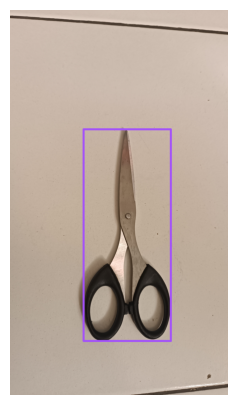

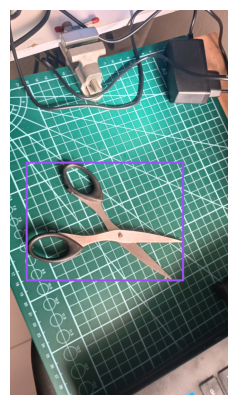

In [9]:
for image_name in image_names[:2]: # [:2] --> get only 2 sample image for checking the box result
  image_name = os.path.join(DATASET_FOLDER, image_name)

  image = images[image_name]
  detections = annotations[image_name]

  box_annotator = sv.BoxAnnotator(thickness=20)
  annotated_image = box_annotator.annotate(scene=image.copy(), detections=detections)

  %matplotlib inline
  sv.plot_image(annotated_image, (5, 5))

## 3.5 Upload Generated Annotation and Image Dataset to Roboflow


- Convert and save `annotations` data into `Pascal VOC` in `.xml` format
- The format is required by Roboflow upload API
- More abount `Pascal VOC `Format (http://host.robots.ox.ac.uk/pascal/VOC/)

In [11]:
import os
HOME = os.getcwd()

In [12]:
ANNOTATIONS_DIRECTORY = os.path.join(HOME, 'annotations')

MIN_IMAGE_AREA_PERCENTAGE = 0.002
MAX_IMAGE_AREA_PERCENTAGE = 0.80
APPROXIMATION_PERCENTAGE = 0.75

# extract class names from ONTOLOGY defined on section 3.4.1 above
CLASSES = list(ONTOLOGY.values())

sv.DetectionDataset(
    classes=CLASSES,
    images=images,
    annotations=annotations
).as_pascal_voc(
    annotations_directory_path=ANNOTATIONS_DIRECTORY,
    min_image_area_percentage=MIN_IMAGE_AREA_PERCENTAGE,
    max_image_area_percentage=MAX_IMAGE_AREA_PERCENTAGE,
    approximation_percentage=APPROXIMATION_PERCENTAGE
)

- Create **Roboflow Project** automatically using bellow script
- The upload proceess will prompting you with `Roboflow Auth Token`,<br>
<img src="https://github.com/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/resource/rb_login.png?raw=1" width="500px"><br><br>
<img src="https://github.com/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/resource/rb-copy-token.png?raw=1" width="800px">

In [13]:
import roboflow
from roboflow import Roboflow

# define new project name in Roboflow
PROJECT_NAME = "scissors-auto-annotate-1"
PROJECT_DESCRIPTION = "scissors-auto-annotate-1"


roboflow.login()

workspace = Roboflow().workspace()
new_project = workspace.create_project(
    project_name=PROJECT_NAME,
    project_license="MIT",
    project_type="object-detection",
    annotation=PROJECT_DESCRIPTION)

visit https://app.roboflow.com/auth-cli to get your authentication token.
Paste the authentication token here: ··········
loading Roboflow workspace...


- Upload `Image Dataset` (.jpg) and `Pascal VOC` (.xml) to newly created Roboflow Project above.

In [14]:
import os
from tqdm.notebook import tqdm

image_paths = sv.list_files_with_extensions(directory=DATASET_FOLDER, extensions=["jpg", "jpeg", "png"])
for image_path in tqdm(image_paths):
    image_name = image_path.name
    annotation_name = f"{image_path.stem}.xml"
    image_path = str(image_path)
    annotation_path = os.path.join(ANNOTATIONS_DIRECTORY, annotation_name)
    new_project.upload(
        image_path=image_path,
        annotation_path=annotation_path,
        split="train",
        is_prediction=True,
        overwrite=True,
        tag_names=["scissors-auto-annotate"],
        batch_name="scissors-auto-annotate"
    )

  0%|          | 0/20 [00:00<?, ?it/s]

- Check the uploaded dataset in Roboflow
- Open Tab `Annotate`, click on unassigned dataset below<br>
<img src="https://github.com/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/resource/rb-auto-uploaded.png?raw=1" width="800px">
- It will showing all uploaded image data with bounding box
- Just click on `Anotate Images` button in top right corner<br>
<img src="https://github.com/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/resource/rb-auto-annotated.png?raw=1" width="800px">
- After that, just click `Manual Labeling` sidebar then click `Assign to Myself`<br>
<img src="https://github.com/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/resource/rb-manual-labeling.png?raw=1" width="300px"><br>
    - <i>Don't worrie, all data is already annotated, so nolonger need to manually annotated the data</i><br><br>
- Click on `Add xx images to Dataset` button in the top right corner<br>
<img src="https://github.com/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/resource/rb-add-dataset.png?raw=1" width="800px">
- Then choose method `Split Images Between Train/Valid/Test` and click `Add images` button <br>
<img src="https://github.com/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/resource/rb-train-test-split.png?raw=1" width="300px">
- Completing the process like in `Pertemuan 4` to add `Preprocessing` and `Augmentation` on dataset until the `Create` process.
<img src="https://github.com/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/resource/rb-finalized.png?raw=1" width="600px">
- Now the dataset ready to use, just click on `Download Dataset` button then choose the format to use like usual<br>
<img src="https://github.com/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/resource/rb-export.png?raw=1" width="800px"><br><br>
- Use that Roboflow Dataset in notebook `5.1 train-yolov8-object-detection-on-custom-dataset.ipynb` by your self<br>
<a href="https://colab.research.google.com/github/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/4.2 train-yolov8-object-detection-on-custom-dataset.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open `5.1 train-yolov8-object-detection-on-custom-dataset.ipynb` In Colab"/></a>

